In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import pymysql
from db_config import DB_HOST, DB_USER, DB_PASSWD, DB_NAME

try:
    with pymysql.connect(
        host=DB_HOST,
        user=DB_USER,
        password=DB_PASSWD,
        database=DB_NAME
        # Notice I deleted the DictCursor line here!
    ) as connection:
        query = "SELECT * FROM project_aqi_api"
        df = pd.read_sql(query, connection)
        
        # Save it to CSV so we never deal with the DB again tonight
        # df.to_csv("aqi_data.csv", index=False)
        print("Data saved to CSV. Connection closed automatically.")
except Exception as e:
    print(f"Error: {e}")

df.head()

Data saved to CSV. Connection closed automatically.


/var/folders/x9/j5dq5m9n5_ddggn66zklqbv80000gn/T/ipykernel_6728/1321854492.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,id,ts,lat,lon,aqi
0,1,2026-03-27 10:02:13,13.86,100.52,77
1,2,2026-03-27 10:12:12,13.86,100.52,77
2,3,2026-03-27 10:22:13,13.86,100.52,78
3,4,2026-03-27 10:32:13,13.86,100.52,79
4,5,2026-03-27 10:42:12,13.86,100.52,79


In [4]:
mask = df.isnull() | (df == 0) | (df == "")

# Filter the original dataframe to show only rows where ANY column is True
print(df[mask.any(axis=1)])

Empty DataFrame
Columns: [id, ts, lat, lon, aqi]
Index: []


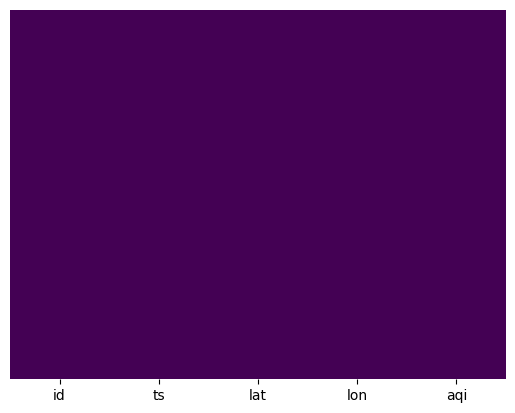

In [5]:
sns.heatmap(df.isnull() | (df == 0) | (df == ""), cbar=False, yticklabels=False, cmap='viridis')
plt.show()

In [6]:
# Define the lower and upper bounds
lower_limit = df['aqi'].quantile(0.01)
upper_limit = df['aqi'].quantile(0.99)

print(f"Lower Limit (0.01%): {lower_limit}")
print(f"Upper Limit (99.99%): {upper_limit}")

Lower Limit (0.01%): 77.0
Upper Limit (99.99%): 105.0


In [7]:
df = df[(df['aqi'] >= lower_limit) & (df['aqi'] <= upper_limit)].copy()
df.head()

,id,ts,lat,lon,aqi
0,1,2026-03-27 10:02:13,13.86,100.52,77
1,2,2026-03-27 10:12:12,13.86,100.52,77
2,3,2026-03-27 10:22:13,13.86,100.52,78
3,4,2026-03-27 10:32:13,13.86,100.52,79
4,5,2026-03-27 10:42:12,13.86,100.52,79


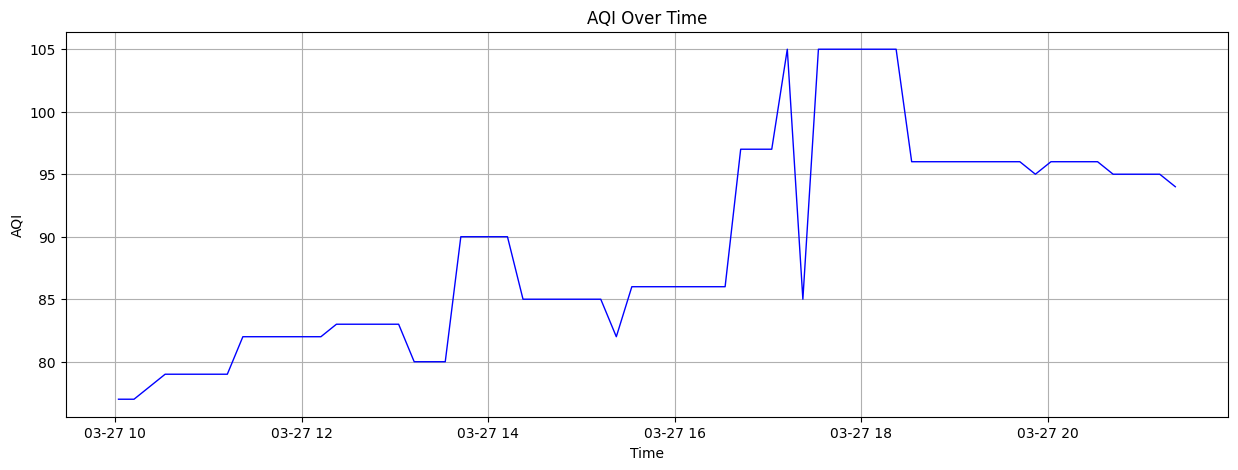

In [9]:
plt.figure(figsize=(15, 5))
plt.plot(df['ts'], df['aqi'], color='blue', linewidth=1)
plt.title('AQI Over Time')
plt.xlabel('Time')
plt.ylabel('AQI')
plt.grid(True)
plt.show()

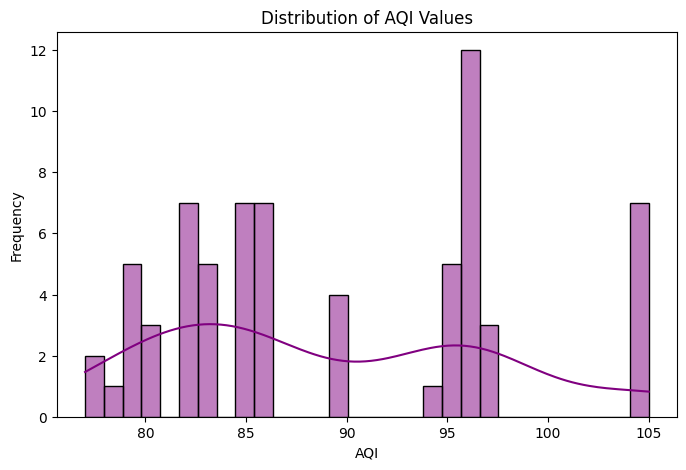

In [10]:
# Add this cell to see the distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['aqi'], bins=30, kde=True, color='purple')
plt.title('Distribution of AQI Values')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.show()

In [8]:
df['ts'] = pd.to_datetime(df['ts'])

In [ ]:
print(df.nunique())

id     69
ts     69
lat     1
lon     1
aqi    14
dtype: int64


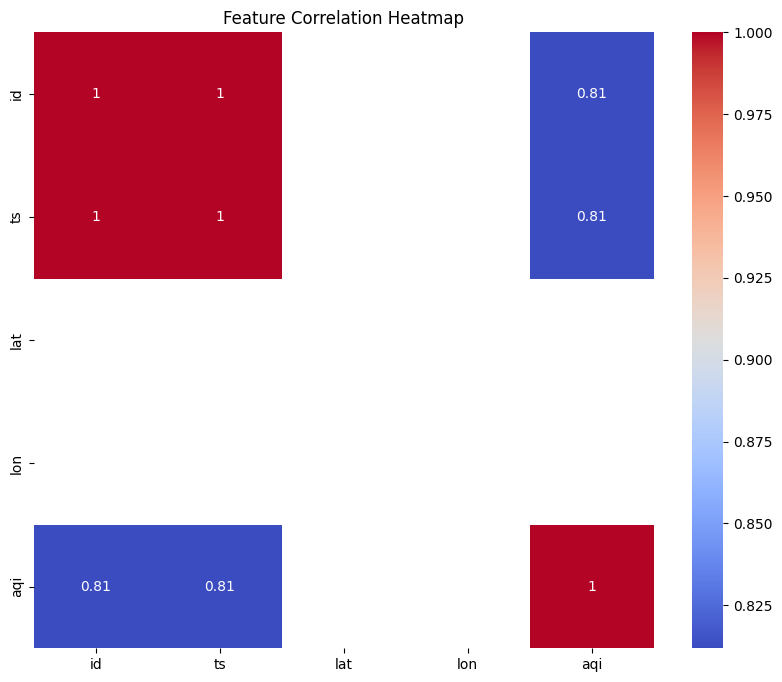

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [20]:
copy_df = df.copy()

In [ ]:
# Drop the constant location columns
copy_df = copy_df.drop(columns=['lat', 'lon'])

# You probably want to drop 'id' as well, since random IDs act as noise in ML
copy_df = copy_df.drop(columns=['id'])

copy_df

,ts,aqi
0,2026-03-27 10:02:13,77
1,2026-03-27 10:12:12,77
2,2026-03-27 10:22:13,78
3,2026-03-27 10:32:13,79
4,2026-03-27 10:42:12,79
...,...,...
64,2026-03-27 20:42:00,95
65,2026-03-27 20:52:00,95
66,2026-03-27 21:02:00,95
67,2026-03-27 21:12:00,95


In [25]:
copy_df.to_csv("aqi_data.csv", index=False)